## Chicago Taxi Fare - Linear Regression

I used linear regression model implemented by myself using NumPy. Below are the some features covered in this notebook:

- train/test split
- feature scaling fitted on the training set
- gradient descent training
- MAE, MSE, RMSE, and R² evaluation
- training, prediction, residual, and 3D regression-plane plots
- safe prediction of completely new trips

*The notebook also demonstrates my practical skills using Python, NumPy, Pandas, and Matplotlib.*

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


##### 1. Loading and preparation of the open-source dataset taken from the Internet


In [18]:

chicago_taxi_dataset = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv")

columns = [
    "TRIP_MILES",
    "TRIP_SECONDS",
    "FARE",
    "COMPANY",
    "PAYMENT_TYPE",
    "TIP_RATE",
]

df = chicago_taxi_dataset.loc[:, columns].copy()

# The model will use minutes, not seconds.
df["TRIP_MINUTES"] = df["TRIP_SECONDS"] / 60.0

model_columns = ["TRIP_MILES", "TRIP_MINUTES", "FARE"]

df = (
    df.replace([np.inf, -np.inf], np.nan)
      .dropna(subset=model_columns)
      .reset_index(drop=True)
)

print(f"Rows available: {len(df):,}")
df.head(5)


Rows available: 31,694


,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE,TRIP_MINUTES
0,2.57,2341,31.99,Flash Cab,Mobile,6.3,39.016667
1,1.18,1074,9.75,Flash Cab,Credit Card,27.9,17.900000
2,1.29,1173,10.25,Sun Taxi,Cash,0.0,19.550000
3,3.70,3360,23.75,Choice Taxi Association,Cash,0.0,56.000000
4,1.15,1044,10.00,Flash Cab,Cash,0.0,17.400000


##### 2. Inspect the data


In [4]:
print("Missing values:")
print(df.isna().sum())

print("\nNumeric summary:")
print(df[["TRIP_MILES", "TRIP_SECONDS", "TRIP_MINUTES", "FARE", "TIP_RATE"]].describe())

print("\nCorrelation matrix:")
df[["TRIP_MILES", "TRIP_MINUTES", "FARE"]].corr(numeric_only=True)


Missing values:
TRIP_MILES      0
TRIP_SECONDS    0
FARE            0
COMPANY         0
PAYMENT_TYPE    0
TIP_RATE        0
TRIP_MINUTES    0
dtype: int64

Numeric summary:
         TRIP_MILES  TRIP_SECONDS  TRIP_MINUTES          FARE      TIP_RATE
count  31694.000000  31694.000000  31694.000000  31694.000000  31694.000000
mean       8.289463   1319.796397     21.996607     23.905210     12.965785
std        7.265672    928.932873     15.482215     16.970022     15.517765
min        0.500000     60.000000      1.000000      3.250000      0.000000
25%        1.720000    548.000000      9.133333      9.000000      0.000000
50%        5.920000   1081.000000     18.016667     18.750000     12.200000
75%       14.500000   1888.000000     31.466667     38.750000     20.800000
max       68.120000   7140.000000    119.000000    159.250000    648.600000

Correlation matrix:


,TRIP_MILES,TRIP_MINUTES,FARE
TRIP_MILES,1.000000,0.800855,0.975344
TRIP_MINUTES,0.800855,1.000000,0.830292
FARE,0.975344,0.830292,1.000000


##### 3. Building exploratory plots

Does the fare increase as trip distance increases? -> Answer: `plot_feature_vs_target`

What are the relationships between multiple numerical values of columns? -> Answer: `plot_correlation_matrix
`

In [5]:
def plot_feature_vs_target(dataset: pd.DataFrame, feature: str, target: str ="FARE", sample_size: int =3000):
    if len(dataset) > sample_size:
        data = dataset.sample(sample_size, random_state=RANDOM_STATE)
    else:
        data = dataset

    plt.figure(figsize=(10, 5))
    plt.scatter(data[feature], data[target], alpha=0.6)

    plt.xlabel(feature)
    plt.ylabel(target)
    plt.title(f"{target} vs {feature}")
    plt.grid(True)
    plt.show()


def plot_correlation_matrix(dataset, columns):
    corr = dataset[columns].corr()

    figure, axes = plt.subplots(figsize=(10, 8))
    matrix_image = axes.imshow(corr, vmin=-1, vmax=1)

    axes.set_xticks(range(len(columns)))
    axes.set_yticks(range(len(columns)))
    axes.set_xticklabels(columns, rotation=90)
    axes.set_yticklabels(columns)

    for row in range(len(columns)):
        for col in range(len(columns)):
            axes.text(col, row, f"{corr.iloc[row, col]:.2f}", ha="center", va="center")

    figure.colorbar(matrix_image, ax=axes, label="Correlation")

    axes.set_title("Correlation Matrix")

    plt.tight_layout()
    plt.show()


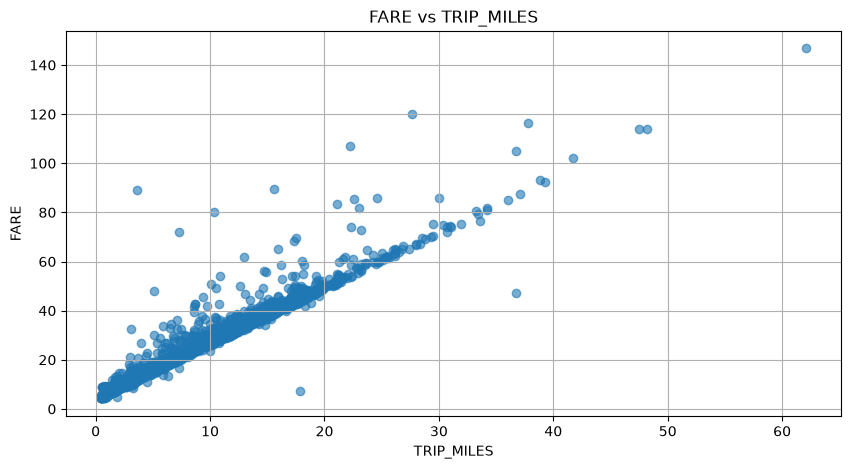

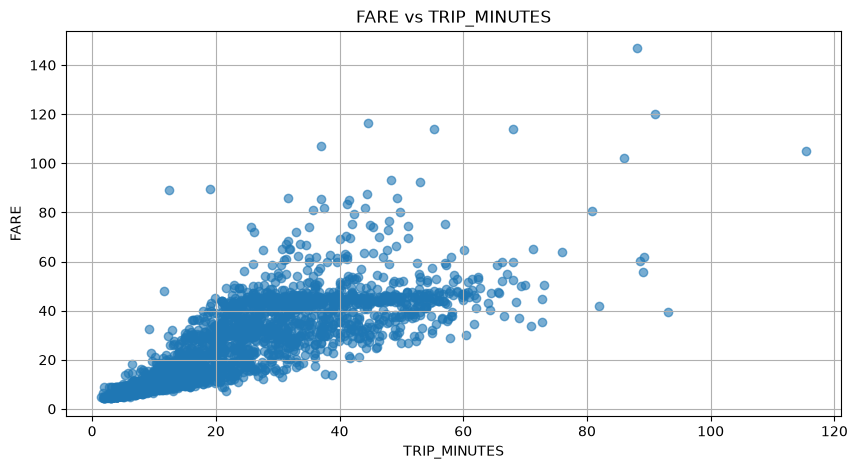

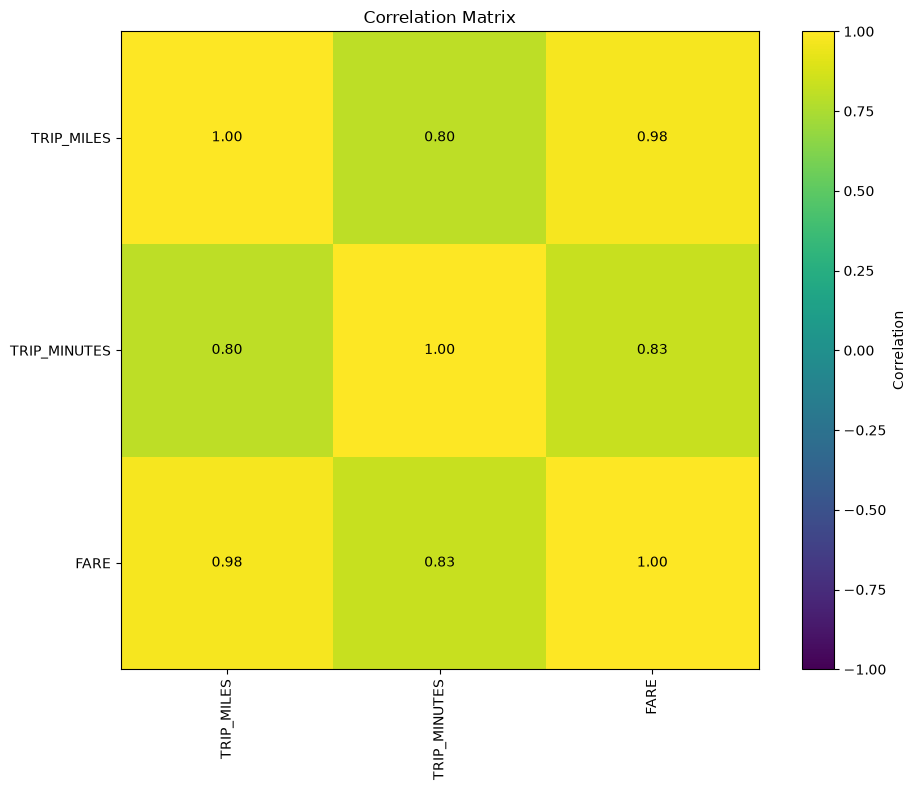

In [27]:
plot_feature_vs_target(df, "TRIP_MILES")

plot_feature_vs_target(df, "TRIP_MINUTES")

plot_correlation_matrix(df, ["TRIP_MILES", "TRIP_MINUTES", "FARE"])


##### 4. Train/test split

In my case, I am assuming that the given dataset is splitted into two parts:
    
    -80% of dataset is for model training
    
    -20% of dataset is for testing the model

In [6]:
def train_test_split_dataframe(dataset: pd.DataFrame, test_size=0.20, random_state=42):
    if not 0 < test_size < 1:
        raise ValueError("test_size must be between 0 and 1.")

    rng = np.random.default_rng(random_state)

    indices = rng.permutation(len(dataset))

    split_index = int(len(dataset) * (1 - test_size))

    train_indices = indices[:split_index]
    test_indices = indices[split_index:]

    train_data = dataset.iloc[train_indices].reset_index(drop=True)

    test_data = dataset.iloc[test_indices].reset_index(drop=True)

    return train_data, test_data

train_df, test_df = train_test_split_dataframe(df,test_size=0.20, random_state=RANDOM_STATE)

print(f"Training rows: {len(train_df):,}")

print(f"Test rows: {len(test_df):,}")

Training rows: 25,355
Test rows: 6,339


##### 5. Model, scaler, and experiment classes


In [ ]:
@dataclass
class ExperimentSettings:
    input_features: list[str]
    learning_rate: float
    number_epochs: int


@dataclass
class FeatureScaler:
    means: np.ndarray
    stds: np.ndarray

    @classmethod
    def fit(cls, X):
        means = X.mean(axis=0)
        stds = X.std(axis=0)

        # Prevent division by zero if a feature is constant.
        stds = np.where(stds == 0, 1.0, stds)

        return cls(means=means, stds=stds)

    def transform(self, X):
        return (X - self.means) / self.stds



class LinearRegressionModel:

    def __init__(self, number_features):
        self.weights = np.zeros(number_features, dtype=float)
        self.bias = 0.0

    def predict(self, X):
        return X @ self.weights + self.bias


@dataclass
class Experiment:
    name: str
    settings: ExperimentSettings
    model: LinearRegressionModel
    scaler: FeatureScaler
    epochs: list[int]
    metrics_history: pd.DataFrame


##### 6. Training and prediction helpers


In [ ]:
def train_model(experiment_name: str, model: LinearRegressionModel, dataset: pd.DataFrame, label_name: str, settings: ExperimentSettings):
    
    X_raw = dataset[settings.input_features].to_numpy(dtype=float)
    y = dataset[label_name].to_numpy(dtype=float)

    # Fitting preprocessing on training data.
    scaler = FeatureScaler.fit(X_raw)

    X = scaler.transform(X_raw)

    n = len(X)

    mse_history = []
    rmse_history = []

    for epoch in range(settings.number_epochs):
        
        # Make a prediction (Forward passing)
        predictions = model.predict(X)

        errors = predictions - y

        # Calculation of the gradients of MSE
        weight_gradients = (2 / n) * (X.T @ errors)
        bias_gradient = (2 / n) * np.sum(errors)

        # Gradient-descent update
        model.weights -= settings.learning_rate * weight_gradients

        model.bias -= settings.learning_rate * bias_gradient

        # Measuring the updated model
        updated_predictions = model.predict(X)

        updated_errors = updated_predictions - y

        mse = np.mean(updated_errors ** 2)
        rmse = np.sqrt(mse)

        mse_history.append(mse)
        rmse_history.append(rmse)

    history = pd.DataFrame({
        "mse": mse_history,
        "rmse": rmse_history,
    })

    return Experiment(
        name=experiment_name,
        settings=settings,
        model=model,
        scaler=scaler,
        epochs=list(range(1,settings.number_epochs + 1)),
        metrics_history=history
    )


def predict_dataset(experiment: Experiment, dataset: pd.DataFrame):
    X_raw = dataset[experiment.settings.input_features].to_numpy(dtype=float)

    X_scaled = experiment.scaler.transform(X_raw)

    return experiment.model.predict(X_scaled)


def original_scale_equation(experiment: Experiment):
    
    '''
    Converting the weights learned on standardized
    features back to the original feature units.
    '''
    scaled_weights = experiment.model.weights
    means = experiment.scaler.means
    stds = experiment.scaler.stds

    original_weights = scaled_weights / stds

    original_bias = experiment.model.bias - np.sum((means / stds) * scaled_weights)

    return original_weights, original_bias


##### 7. Evaluation metrics


In [9]:
def regression_metrics(y_actual, y_predicted):
    
    errors = y_predicted - y_actual
    mae = np.mean(np.abs(errors))
    mse = np.mean(errors ** 2)
    rmse = np.sqrt(mse)

    ss_res = np.sum((y_actual - y_predicted) ** 2)

    ss_total = np.sum((y_actual - np.mean(y_actual)) ** 2)

    r2 = np.nan if ss_total == 0 else 1 - ss_res / ss_total

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
    }


def evaluate_model(experiment: Experiment, dataset: pd.DataFrame, label_name="FARE"):
    
    y_actual = dataset[label_name].to_numpy(dtype=float)
    y_predicted = predict_dataset(experiment, dataset)

    return regression_metrics(y_actual=y_actual, y_predicted=y_predicted)


def metrics_table(experiment: Experiment, train_data: pd.DataFrame, test_data: pd.DataFrame, label_name="FARE"):
    
    train_metrics = evaluate_model(experiment, train_data, label_name)

    test_metrics = evaluate_model(experiment, test_data, label_name)

    return pd.DataFrame(
        [
            train_metrics,
            test_metrics
        ],
        index=[
            "Train",
            "Test"
        ]
    )


##### 8. Diagnostic plotting functions


In [ ]:
def plot_training_history(experiment: Experiment):
    
    plt.figure(figsize=(10, 5))

    plt.plot(experiment.epochs, experiment.metrics_history["rmse"])

    plt.xlabel("Epoch")
    plt.ylabel("RMSE")

    plt.title(f"Training RMSE - {experiment.name}")

    plt.grid(True)
    plt.show()


def plot_actual_vs_predicted(experiment: Experiment, dataset: pd.DataFrame, label_name="FARE"):
    
    y_actual = dataset[label_name].to_numpy(dtype=float)
    y_predicted = predict_dataset(experiment, dataset)

    minimum = min(y_actual.min(), y_predicted.min())

    maximum = max(y_actual.max(), y_predicted.max())

    plt.figure(figsize=(7, 7))

    plt.scatter(y_actual, y_predicted, alpha=0.4)

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        label="Perfect prediction"
    )

    plt.xlabel("Actual fare")
    plt.ylabel("Predicted fare")

    plt.title(f"Actual vs Predicted - {experiment.name}")

    plt.legend()
    plt.grid(True)
    plt.show()


def plot_residuals(experiment: Experiment, dataset: pd.DataFrame, label_name="FARE"):
    y_actual = dataset[label_name].to_numpy(dtype=float)
    y_predicted = predict_dataset(experiment, dataset)

    residuals = y_actual - y_predicted

    plt.figure(figsize=(9, 5))

    plt.scatter(y_predicted, residuals, alpha=0.45)

    plt.axhline(y=0, linestyle="--")

    plt.xlabel("Predicted fare")
    plt.ylabel("Residual (actual - predicted)")

    plt.title(f"Residuals vs Predicted Fare - {experiment.name}")

    plt.grid(True)
    plt.show()

def plot_actual_and_predicted_fares(experiment: Experiment, dataset: pd.DataFrame, label_name="FARE", number_points=50):
    
    y_actual = dataset[label_name].to_numpy(dtype=float)
    y_predicted = predict_dataset(experiment, dataset)

    comparison = pd.DataFrame({
        "Actual": y_actual,
        "Predicted": y_predicted
    }).sort_values("Actual").reset_index(drop=True)

    number_points = min(number_points, len(comparison))

    indices = np.linspace(0, len(comparison) - 1, number_points,dtype=int)

    sample = comparison.iloc[indices].reset_index(drop=True)

    plt.figure(figsize=(12, 5))

    plt.plot(sample.index, sample["Actual"], marker="o", label="Actual")
    plt.plot(sample.index, sample["Predicted"], marker="o", label="Predicted")

    plt.xlabel("Selected test observations (sorted by actual fare)")
    plt.ylabel("Fare")

    plt.title(f"Actual vs Predicted Fares - {experiment.name}")

    plt.legend()
    plt.grid(True)
    plt.show()


def plot_regression_plane(experiment, dataset, label_name="FARE", sample_size=1500):
    feature_1, feature_2 = experiment.settings.input_features

    if len(dataset) > sample_size:
        sample = dataset.sample(sample_size, random_state=RANDOM_STATE)
    else:
        sample = dataset

    x1_low, x1_high = dataset[feature_1].quantile([0.01, 0.99])

    x2_low, x2_high = dataset[feature_2].quantile([0.01, 0.99])

    x1_grid = np.linspace(x1_low, x1_high, 30)

    x2_grid = np.linspace(x2_low, x2_high,30)

    grid_x1, grid_x2 = np.meshgrid(x1_grid, x2_grid)

    grid_raw = np.column_stack([
        grid_x1.ravel(),
        grid_x2.ravel()
    ])

    grid_scaled = experiment.scaler.transform(grid_raw)

    grid_predictions = experiment.model.predict(grid_scaled).reshape(grid_x1.shape)

    fig = plt.figure(figsize=(12, 8))

    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(sample[feature_1], sample[feature_2], sample[label_name], alpha=0.25)

    ax.plot_surface(grid_x1, grid_x2, grid_predictions, alpha=0.35)
    ax.set_xlabel(feature_1)
    ax.set_ylabel(feature_2)
    ax.set_zlabel(label_name)

    ax.set_title("Linear Regression Plane")

    plt.show()


##### 9. Train the model


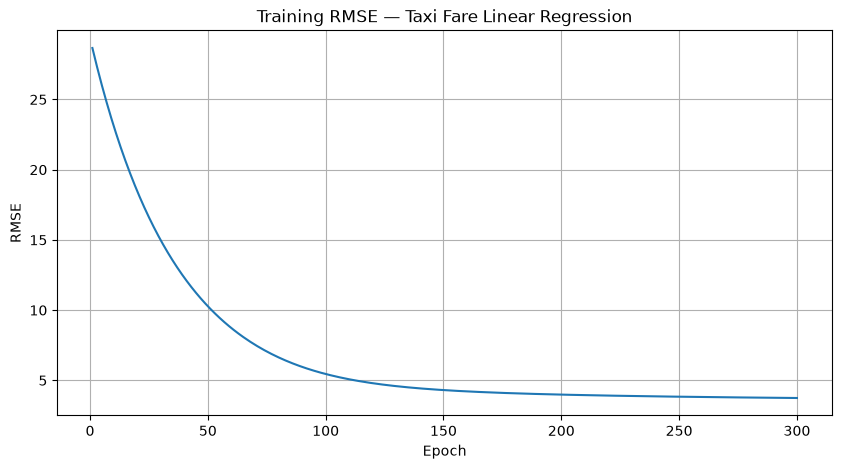

In [12]:
settings_1 = ExperimentSettings(
    input_features=[
        "TRIP_MILES",
        "TRIP_MINUTES"
    ],
    learning_rate=0.01,
    number_epochs=300
)

model_1 = LinearRegressionModel(number_features=len(settings_1.input_features))

experiment_1 = train_model(
    experiment_name="Taxi Fare Linear Regression",
    model=model_1,
    dataset=train_df,
    label_name="FARE",
    settings=settings_1
)

plot_training_history(experiment_1)


##### 10. Evaluate on both training and unseen test data


In [14]:
results = metrics_table(
    experiment=experiment_1,
    train_data=train_df,
    test_data=test_df,
    label_name="FARE"
)

display(results.round(4))

weights_original, bias_original = original_scale_equation(experiment_1)

print("\nModel equation in original units:")

print(
    f"FARE ≈ "
    f"{weights_original[0]:.4f} * TRIP_MILES + "
    f"{weights_original[1]:.4f} * TRIP_MINUTES + "
    f"{bias_original:.4f}"
)


,MAE,MSE,RMSE,R2
Train,1.5271,14.0129,3.7434,0.9515
Test,1.4726,11.3958,3.3758,0.9598



Model equation in original units:
FARE ≈ 1.7629 * TRIP_MILES + 0.2715 * TRIP_MINUTES + 3.2710


##### 11. Model-quality graphs


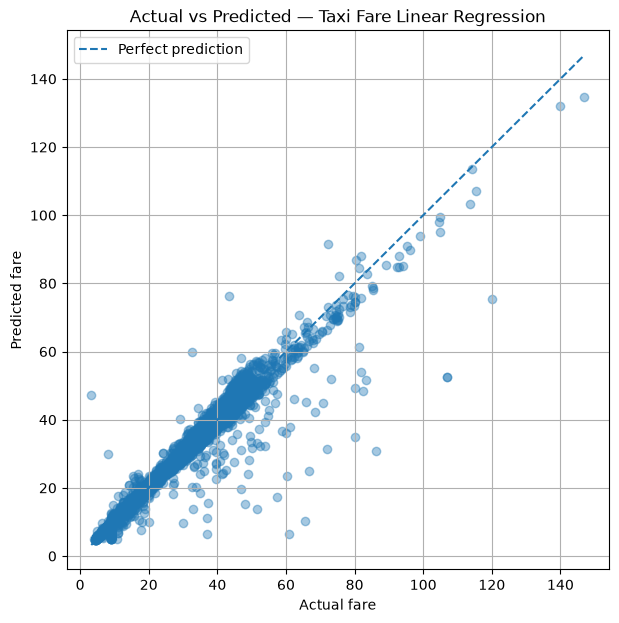

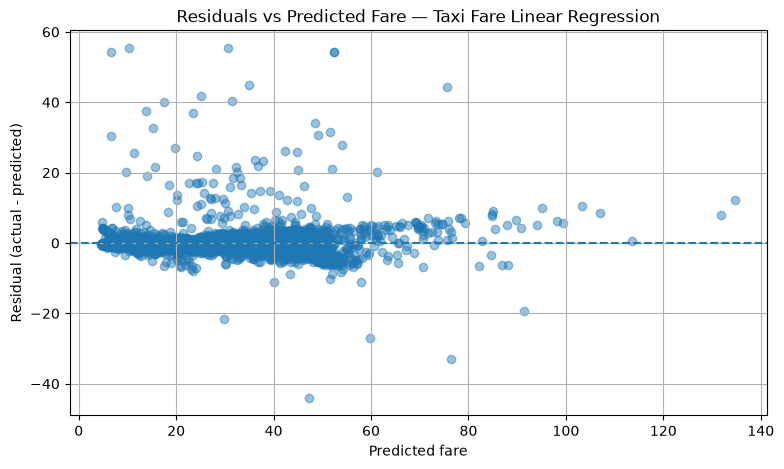

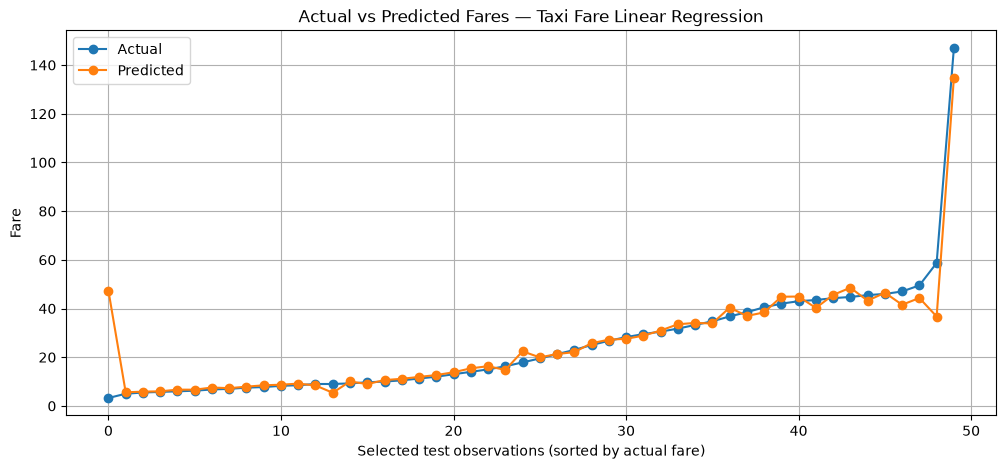

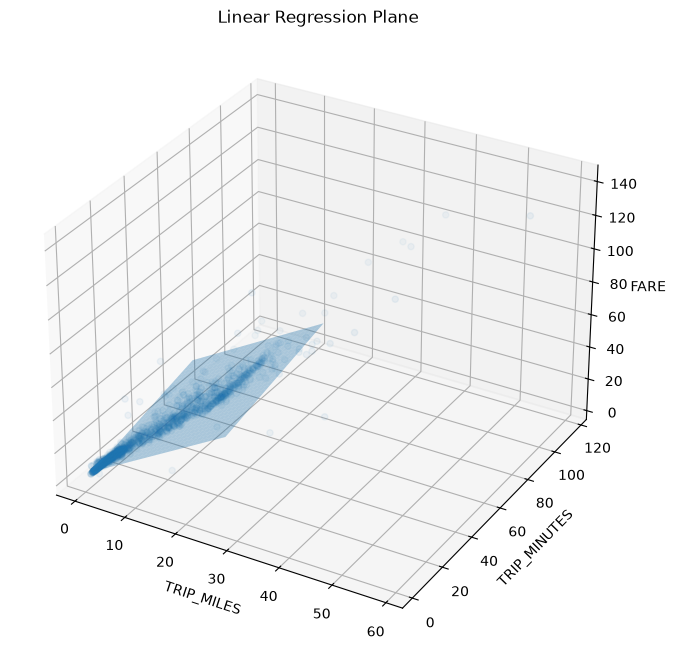

In [15]:
plot_actual_vs_predicted(experiment_1, test_df, "FARE")

plot_residuals(experiment_1, test_df, "FARE")

plot_actual_and_predicted_fares(experiment_1, test_df, "FARE", number_points=50)

plot_regression_plane(experiment_1, test_df, "FARE")


##### 12. Predict completely new trips


In [17]:
def predict_new_trips(experiment: Experiment, trips: pd.DataFrame):
    '''
    Required input columns: TRIP_MILES and TRIP_SECONDS

    The function converts seconds to minutes,
    applies the scaler learned from training data,
    and predicts FARE.
    '''

    required_columns = {"TRIP_MILES", "TRIP_SECONDS"}

    missing = required_columns - set(trips.columns)

    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    result = trips.copy()

    if (result["TRIP_MILES"] < 0).any():
        raise ValueError("TRIP_MILES cannot be negative.")

    if (result["TRIP_SECONDS"] < 0).any():
        raise ValueError("TRIP_SECONDS cannot be negative.")

    # Convert units automatically.
    result["TRIP_MINUTES"] = result["TRIP_SECONDS"] / 60.0

    X_raw = result[experiment.settings.input_features].to_numpy(dtype=float)
    X_scaled = experiment.scaler.transform(X_raw)

    result["PREDICTED_FARE"] = experiment.model.predict(X_scaled)

    return result


new_trips = pd.DataFrame({
    "TRIP_MILES": [
        4.5,
        1.2,
        8.0
    ],
    "TRIP_SECONDS": [
        700,
        1200,
        1100
    ]
})

predicted_trips = predict_new_trips(experiment_1, new_trips)

display(predicted_trips.round(2))


,TRIP_MILES,TRIP_SECONDS,TRIP_MINUTES,PREDICTED_FARE
0,4.5,700,11.67,14.37
1,1.2,1200,20.00,10.82
2,8.0,1100,18.33,22.35
